## Introducción

La diabetes es una de las enfermedades crónicas más prevalentes a nivel mundial, y su diagnóstico temprano puede marcar una diferencia significativa en la calidad de vida de los pacientes. En este artículo, exploraremos cómo el aprendizaje automático (*machine learning*) puede apoyar la detección temprana de esta enfermedad a partir de datos clínicos.

Utilizaremos el conocido dataset **Pima Indians Diabetes**, que contiene información médica de mujeres de la comunidad Pima y una etiqueta binaria que indica si la paciente desarrolló diabetes. A lo largo del análisis, aplicaremos dos de los algoritmos de clasificación más populares y comprensibles en el campo del ML:

- **Árbol de Decisión** (*Decision Tree Classifier*): un modelo interpretable que divide los datos en función de reglas simples.
- **Random Forest**: un conjunto (*ensemble*) de árboles de decisión que generalmente produce predicciones más robustas.

El flujo del análisis cubrirá desde la carga y limpieza de los datos, pasando por el manejo de valores faltantes, la exploración visual, el entrenamiento de modelos, hasta la evaluación final de su desempeño. Al final compararemos ambos enfoques bajo dos estrategias distintas de tratamiento de datos faltantes.

---
## 1. Importación de Librerías

Comenzamos importando todas las librerías necesarias para el análisis. Estas se pueden agrupar en:
- **Manipulación de datos**: `pandas`, `numpy`
- **Visualización**: `matplotlib`, `seaborn`
- **Modelado y evaluación**: módulos de `scikit-learn`

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Herramientas para visualizar el árbol de decisión
from sklearn.tree import plot_tree
from sklearn import preprocessing

# División del dataset en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Métricas de evaluación para regresión
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

# Modelos de árbol de decisión y random forest (clasificación y regresión)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Utilidades para curvas de aprendizaje y validación cruzada
from sklearn.model_selection import learning_curve
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import cross_val_score

# Métricas de evaluación para clasificación
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Validación cruzada con K-Folds
from sklearn.model_selection import KFold

# Escalado de características
from sklearn.preprocessing import MinMaxScaler

import seaborn as sb
from numpy import nan

---
## 2. Configuración Global

Definimos una **semilla aleatoria** para garantizar la **reproducibilidad** de los experimentos. Al fijar esta semilla, cualquier persona que ejecute este notebook obtendrá exactamente los mismos resultados.

In [4]:
# Semilla aleatoria fija para reproducibilidad de resultados
semilla_aleatoria = 6789

---
## 3. Carga y Exploración Inicial de los Datos

### 3.1 Carga del Dataset

Cargamos el archivo CSV que contiene el dataset de diabetes. Es buena práctica verificar las primeras filas y el número total de registros inmediatamente después de la carga.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'pima-indians-diabetes-database' dataset.
Path to dataset files: /kaggle/input/pima-indians-diabetes-database


In [6]:
import os

# Listar los archivos y directorios dentro de la ruta especificada
files_in_path = os.listdir(path)

print(f"Archivos y directorios en {path}:")
for item in files_in_path:
    print(item)

Archivos y directorios en /kaggle/input/pima-indians-diabetes-database:
diabetes.csv


In [8]:
# Cargamos el dataset desde el archivo CSV
df_base = pd.read_csv(path + "/diabetes.csv")

# Mostramos las primeras 5 filas para una vista rápida de la estructura
display(df_base.head(5))

# Verificamos cuántos registros tiene el dataset
print(f'El dataset tiene {df_base.shape[0]} registros')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


El dataset tiene 768 registros


### 3.2 Información General del Dataset

`df.info()` nos muestra los tipos de datos de cada columna y si hay valores nulos. Es el primer diagnóstico de calidad del dataset.

In [9]:
# Revisamos los tipos de datos, cantidad de registros no nulos por columna
# y uso de memoria del dataframe
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### 3.3 Análisis de Valores Nulos

Verificamos si existen valores nulos explícitos en el dataset. Sin embargo, en este dataset los valores faltantes están codificados como **ceros**, lo que analizaremos más adelante.

In [10]:
# Contamos los valores nulos por columna
count_null = df_base.isnull().sum()

# Filtramos solo las columnas que tienen al menos un valor nulo
cols_null = count_null[count_null > 0]

# Convertimos a porcentaje para mejor interpretación
cols_null = (cols_null / df_base.shape[0]) * 100
display(cols_null)

,0


### 3.4 Distribución de Variables

Los histogramas nos permiten visualizar la distribución de cada variable. Esto nos ayuda a identificar:
- Variables sesgadas (skewed)
- Posibles valores atípicos
- Variables con muchos ceros (posibles datos faltantes enmascarados)

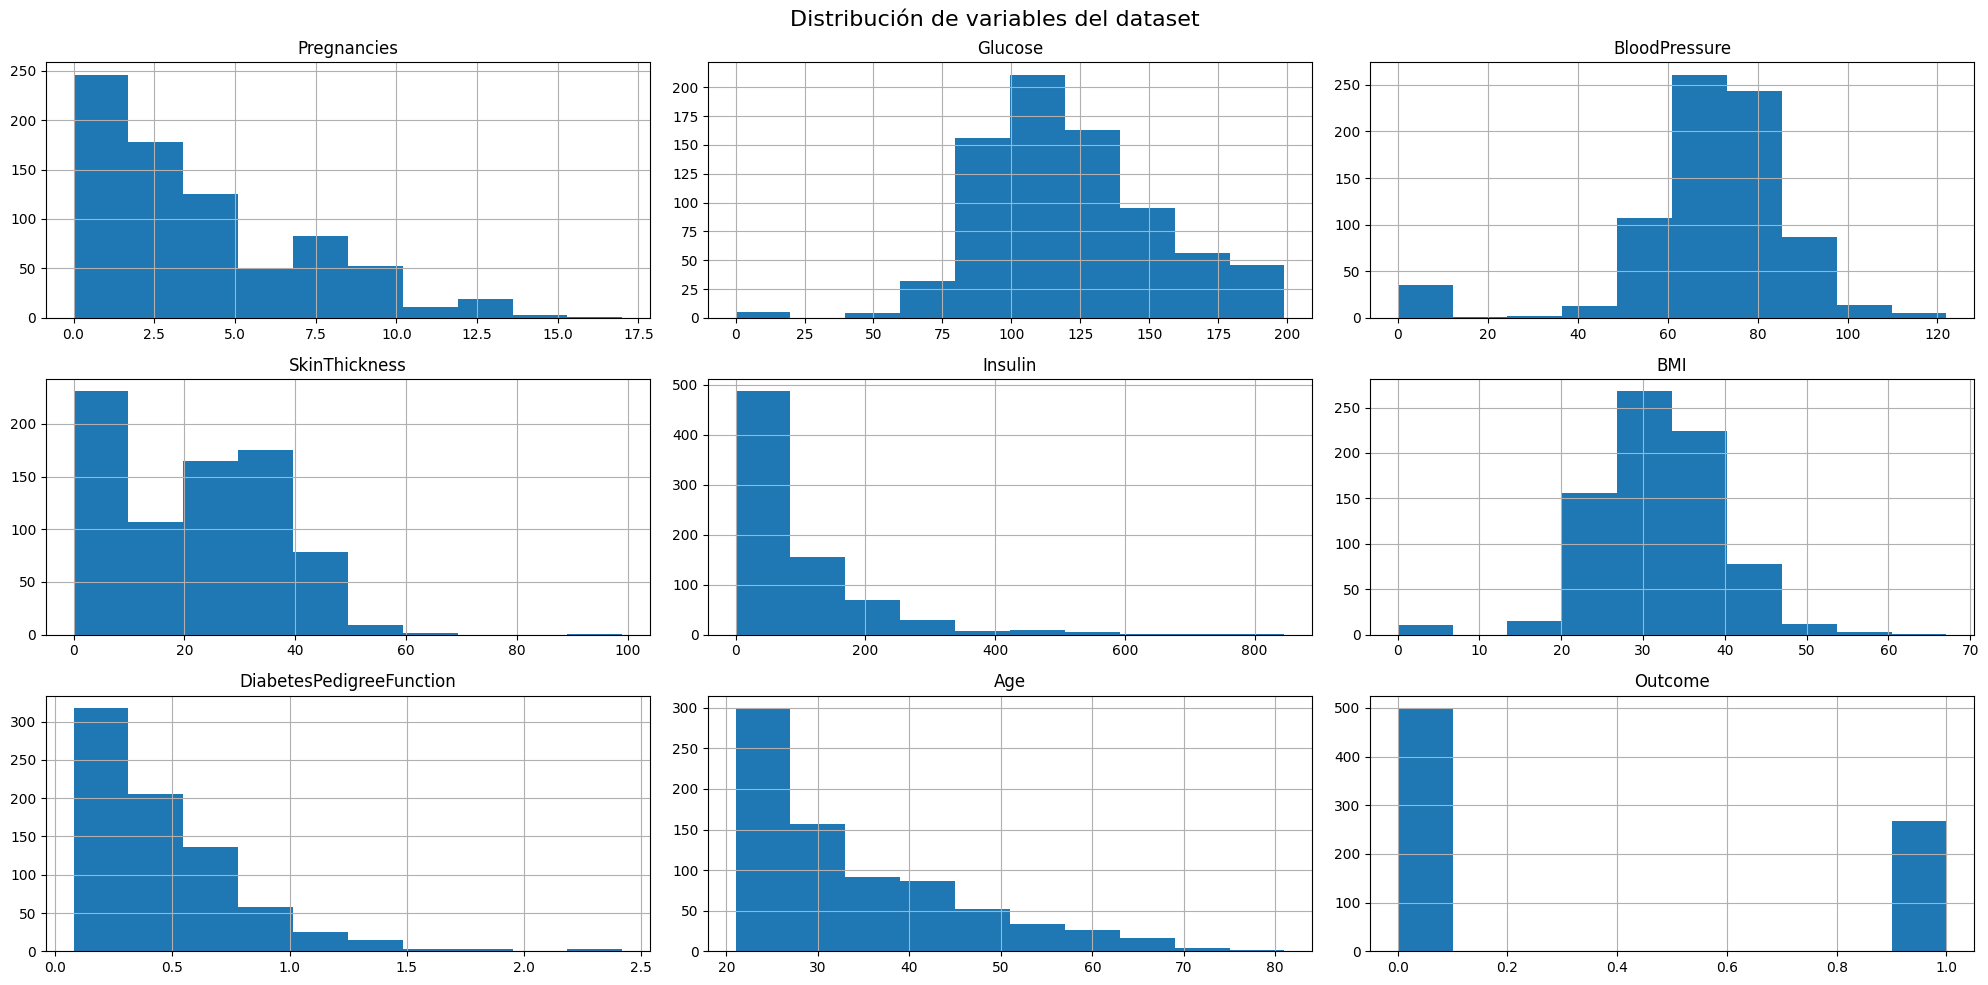

In [11]:
# Ajustamos el tamaño de figura para mejor visualización
plt.rcParams['figure.figsize'] = [20, 10]

# Graficamos histogramas de todas las columnas numéricas
df_base.hist()
plt.suptitle('Distribución de variables del dataset', fontsize=16)
plt.tight_layout()
plt.show()

### 3.5 Estadísticas Descriptivas

`describe()` nos da un resumen estadístico: mínimo, máximo, media, desviación estándar y percentiles. Observar mínimos de **0** en variables como glucosa o presión arterial confirma que hay datos faltantes codificados.

In [12]:
# Estadísticas descriptivas: media, desviación estándar, mínimo, máximo y cuartiles
df_base.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 3.6 Detección de Ceros como Datos Faltantes

En este dataset, un valor de **0** en variables como glucosa, presión arterial, grosor del pliegue cutáneo, insulina e IMC es **médicamente imposible**, por lo que representa datos faltantes. Cuantificamos cuántos hay por columna.

In [13]:
# Contamos cuántos ceros existen en cada columna
# En variables clínicas, un cero generalmente implica dato no registrado
(df_base == 0).sum(axis=0)

,0
Pregnancies,111
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,500


---
## 4. Tratamiento de Datos Faltantes

Exploraremos **dos estrategias** para manejar los ceros problemáticos:

| Estrategia | Descripción |
|---|---|
| **Eliminación** (`dropna`) | Reemplazamos ceros por `NaN` y eliminamos las filas con datos faltantes |
| **Interpolación lineal** | Reemplazamos ceros por `NaN` y estimamos el valor faltante mediante interpolación |

Luego compararemos el impacto de cada estrategia en el desempeño de los modelos.

### 4.1 Reemplazo de Ceros por NaN

In [15]:
# Columnas donde el valor 0 no tiene sentido fisiológico
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# Creamos una copia del dataframe original para no modificarlo
df_ceros_por_nan = df_base.copy()

# Reemplazamos los ceros en las columnas problemáticas por NaN
df_ceros_por_nan[cols] = df_ceros_por_nan[cols].replace({'0': np.nan, 0: np.nan})

# Verificamos cuántos valores faltantes hay ahora por columna
print("Valores faltantes por columna después del reemplazo:")
print(df_ceros_por_nan.isnull().sum())

Valores faltantes por columna después del reemplazo:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


### 4.2 Estrategia A: Interpolación Lineal

La **interpolación lineal** estima los valores faltantes basándose en los valores vecinos en el dataset. Es útil cuando los datos tienen cierta continuidad o tendencia. Se aplica en dirección `forward` (hacia adelante en el índice).

In [16]:
# Creamos una copia para aplicar interpolación sin afectar el df original con NaN
df_base_missing_interpo = df_ceros_por_nan.copy()

# Interpolación lineal hacia adelante: rellena NaN con valores intermedios entre vecinos
df_base_missing_interpo = df_base_missing_interpo.interpolate(method='linear', limit_direction='forward')

# Verificamos que no queden valores faltantes (debería mostrar 0)
display('Verificación de datos faltantes: {0}'.format(df_base_missing_interpo.isnull().sum().max()))

'Verificación de datos faltantes: 3'

### 4.3 Estrategia B: Eliminación de Filas con Datos Faltantes

Otra opción es simplemente **eliminar** los registros que tienen valores faltantes. Esto es más conservador (perdemos información), pero garantiza que trabajamos únicamente con datos completos y confiables.

In [17]:
# Eliminamos todas las filas que contienen al menos un NaN
df_dropna = df_ceros_por_nan.copy().dropna()

print(f'Registros originales: {df_base.shape[0]}')
print(f'Registros tras dropna: {df_dropna.shape[0]}')
print(f'Registros eliminados: {df_base.shape[0] - df_dropna.shape[0]}')

Registros originales: 768
Registros tras dropna: 392
Registros eliminados: 376


---
## 5. Análisis Exploratorio: Mapas de Correlación

Un **mapa de calor de correlaciones** (heatmap) nos muestra qué tan relacionadas están las variables entre sí. Los valores cercanos a **1** o **-1** indican correlación alta; cercanos a **0** indican poca relación.

Comparamos ambos datasets para ver si la estrategia de imputación afecta las relaciones entre variables.

### 5.1 Correlaciones — Dataset con Interpolación

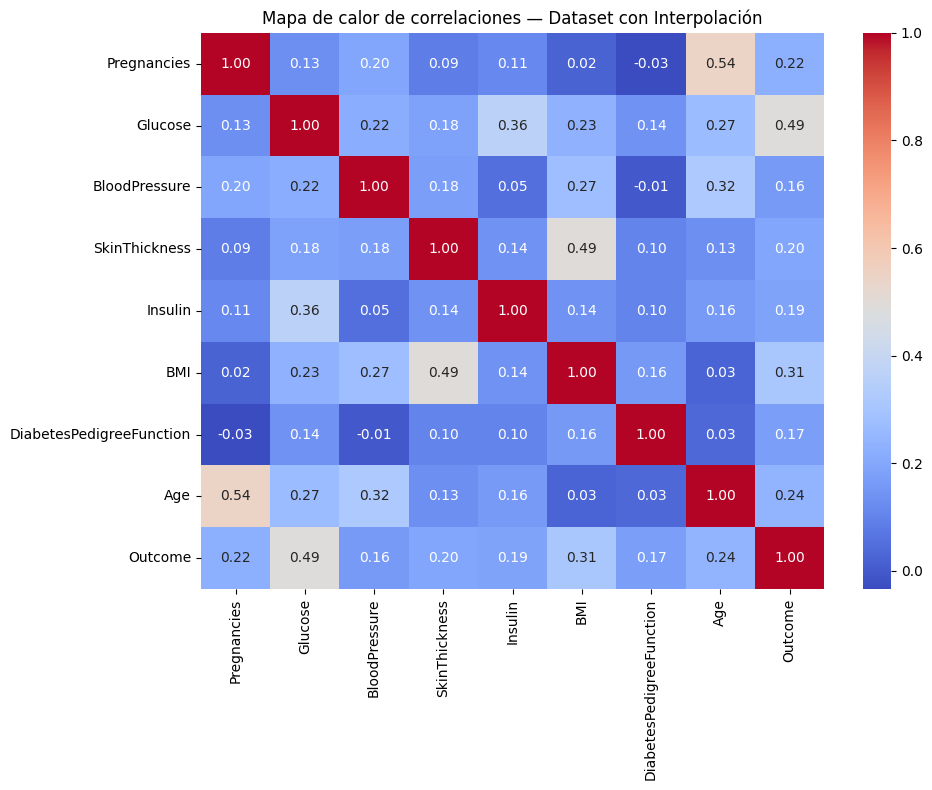

In [18]:
plt.figure(figsize=(10, 8))
# annot=True muestra los valores numéricos dentro de cada celda
# cmap='coolwarm': rojo = correlación positiva, azul = correlación negativa
sb.heatmap(df_base_missing_interpo.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de calor de correlaciones — Dataset con Interpolación")
plt.tight_layout()
plt.show()

### 5.2 Correlaciones — Dataset con Eliminación de Filas (dropna)

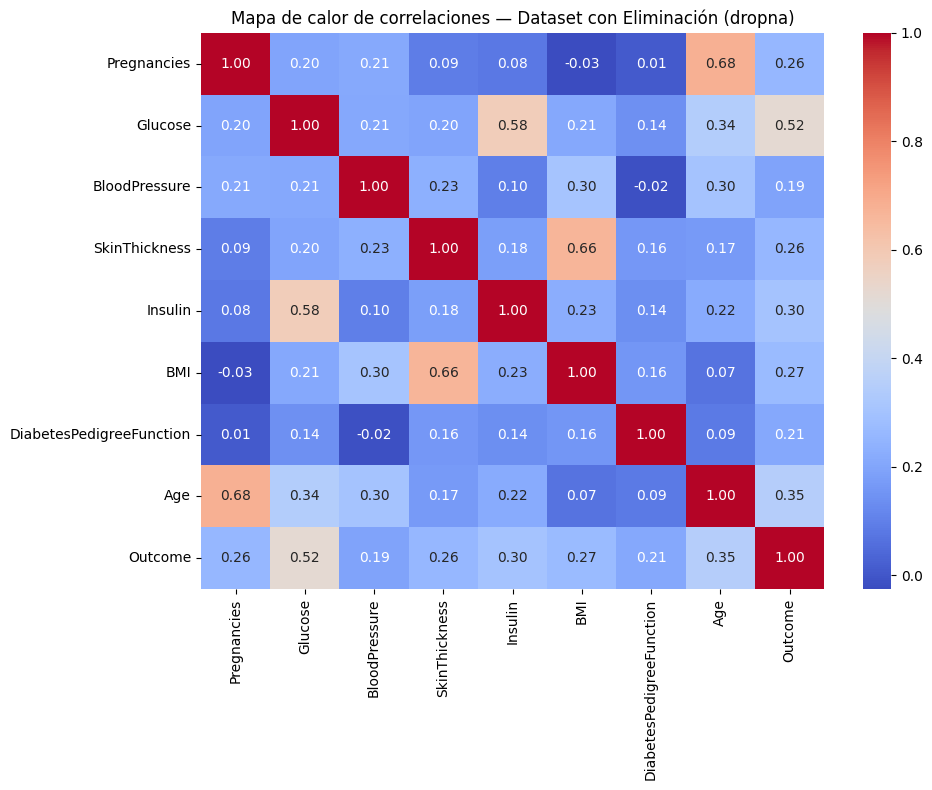

In [19]:
# CORRECCIÓN: Este bloque fue movido DESPUÉS de la definición de df_dropna
# En el notebook original estaba antes, causando un NameError
plt.figure(figsize=(10, 8))
sb.heatmap(df_dropna.corr(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Mapa de calor de correlaciones — Dataset con Eliminación (dropna)")
plt.tight_layout()
plt.show()

---
## 6. Experimento 1: Modelos con Dataset Reducido (dropna)

En este primer experimento entrenamos y evaluamos los modelos usando el dataset donde se **eliminaron** las filas con valores faltantes. Esto nos da una línea base con datos limpios pero con menos muestras.

### 6.1 Preparación del Dataset — Separación de Features y Target

In [20]:
# Configuramos el Árbol de Decisión con hiperparámetros específicos:
# - max_depth=15: limita la profundidad máxima para evitar sobreajuste severo
# - max_features='sqrt': en cada split, considera raíz cuadrada del total de features
# - min_samples_leaf=1: cada hoja puede tener como mínimo 1 muestra
# - splitter='best': en cada nodo elige la mejor división posible
decision_tree = DecisionTreeClassifier(
    max_depth=15,
    max_features='sqrt',
    min_samples_leaf=1,
    random_state=semilla_aleatoria,
    splitter='best'
)
print("Árbol de decisión configurado:", decision_tree)

Árbol de decisión configurado: DecisionTreeClassifier(max_depth=15, max_features='sqrt', random_state=6789)


In [23]:
# X contiene las variables predictoras (features); excluimos la columna objetivo 'Outcome'
X = df_dropna.drop('Outcome', axis=1)

# y contiene la variable objetivo: 1 = tiene diabetes, 0 = no tiene diabetes
y = df_dropna['Outcome']

# Dividimos en 80% entrenamiento y 20% prueba
# random_state asegura que la división sea siempre la misma
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=semilla_aleatoria)

print(f'Tamaño entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño prueba: {X_test.shape[0]} muestras')

Tamaño entrenamiento: 313 muestras
Tamaño prueba: 79 muestras


### 6.2 Normalización de Features

Aplicamos **MinMaxScaler** para escalar todas las variables al rango [0, 1]. Esto es importante porque algunos algoritmos son sensibles a la escala de las variables.

> **⚠️ Importante:** El scaler se ajusta (`fit`) **solo con los datos de entrenamiento** y luego se aplica (`transform`) tanto a entrenamiento como a prueba. Esto evita **data leakage** (filtración de información del conjunto de prueba al entrenamiento).

In [24]:
# Creamos el normalizador MinMaxScaler
norm = MinMaxScaler()

# Ajustamos el scaler SOLO con los datos de entrenamiento
norm.fit(X_train)

# Transformamos tanto entrenamiento como prueba usando los parámetros del entrenamiento
X_train = norm.transform(X_train)
X_test = norm.transform(X_test)

### 6.3 Entrenamiento del Árbol de Decisión

In [25]:
# Entrenamos el modelo con los datos de entrenamiento normalizados
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, max_features='sqrt', random_state=6789)

### 6.4 Validación Cruzada (Cross-Validation)

La **validación cruzada con k=5 folds** divide el conjunto de entrenamiento en 5 partes iguales, entrena con 4 y valida con 1, rotando el fold de validación. Esto nos da una estimación más confiable del desempeño real del modelo.

In [26]:
# Evaluamos el modelo con validación cruzada de 5 folds sobre datos de entrenamiento
scores_dt = cross_val_score(decision_tree, X_train, y_train, cv=5)

print("Accuracy por fold:", scores_dt)
print("%0.2f accuracy con una desviación estándar de %0.2f" % (scores_dt.mean(), scores_dt.std()))

Accuracy por fold: [0.68253968 0.63492063 0.6984127  0.77419355 0.72580645]
0.70 accuracy con una desviación estándar de 0.05


### 6.5 Profundidad y Hojas del Árbol

Inspeccionamos la estructura del árbol. Un árbol muy profundo con muchas hojas es señal de **sobreajuste** (memoriza los datos de entrenamiento en lugar de aprender patrones generalizables).

In [27]:
# La profundidad del árbol indica cuántos niveles de decisión tiene
print(f'La profundidad del árbol es {decision_tree.get_depth()}')

# El número de hojas es la cantidad de decisiones finales (predicciones posibles)
print(f'El número de hojas del árbol es {decision_tree.get_n_leaves()}')

La profundidad del árbol es 15
El número de hojas del árbol es 70


### 6.6 Predicciones y Matriz de Confusión — Árbol de Decisión (Exp. 1)

La **matriz de confusión** muestra:
- **TP** (Verdaderos Positivos): predijo diabetes y el paciente sí la tiene
- **TN** (Verdaderos Negativos): predijo no-diabetes y el paciente no la tiene
- **FP** (Falsos Positivos): predijo diabetes pero el paciente no la tiene
- **FN** (Falsos Negativos): predijo no-diabetes pero el paciente sí la tiene ← el más costoso clínicamente

In [28]:
# Generamos las predicciones sobre el conjunto de prueba
predictions = decision_tree.predict(X_test)

In [29]:
# Calculamos la matriz de confusión comparando etiquetas reales vs. predichas
confusion_mat_DTC = confusion_matrix(y_test, predictions)

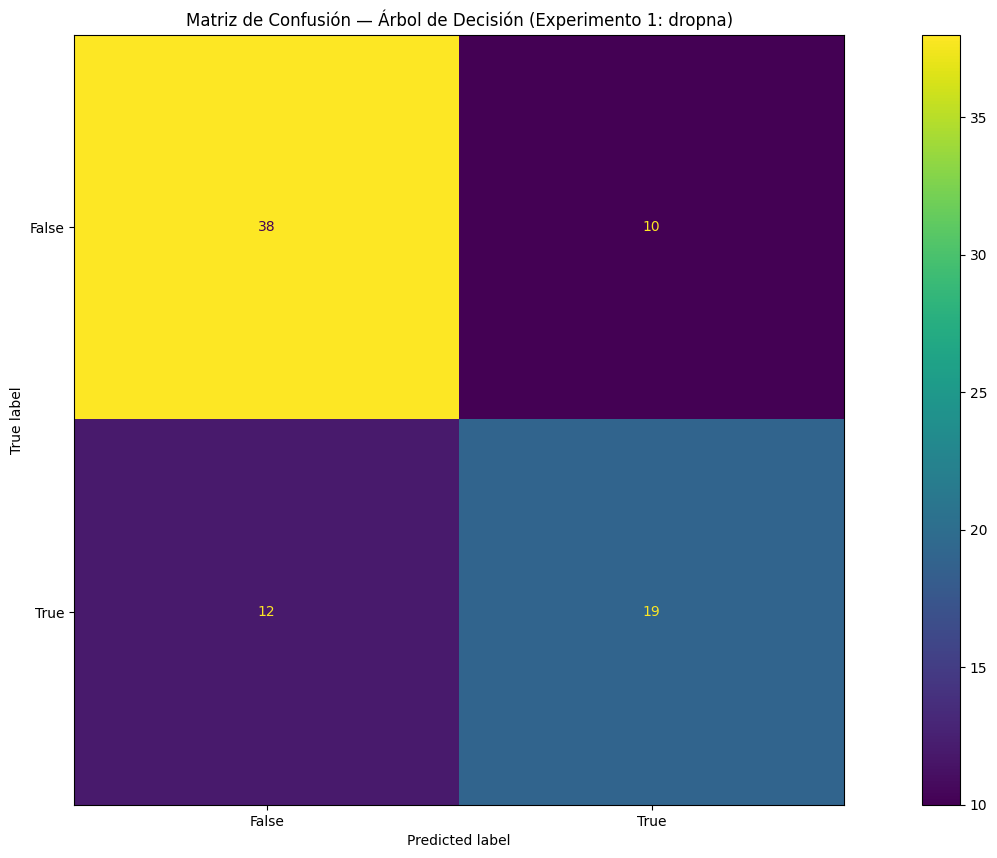

In [30]:
# Visualizamos la matriz de confusión con etiquetas descriptivas
ConfusionMatrixDisplay(confusion_matrix=confusion_mat_DTC, display_labels=[False, True]).plot()
plt.title('Matriz de Confusión — Árbol de Decisión (Experimento 1: dropna)')
plt.show()

**Resultados Experimento 1 — Árbol de Decisión:**
- TP: 13
- TN: 42
- FP: 13
- FN: 11

### 6.7 Random Forest — Experimento 1

El **Random Forest** es un *ensemble* (conjunto) de múltiples árboles de decisión. Cada árbol se entrena con una muestra aleatoria del dataset (*bootstrapping*) y con un subconjunto aleatorio de features. La predicción final se obtiene por votación mayoritaria.

Sus ventajas sobre un único árbol:
- Menor sobreajuste
- Mayor estabilidad
- Generalmente mejor accuracy

In [31]:
# Configuramos el Random Forest:
# - n_estimators=100: usamos 100 árboles en el ensemble
# - max_features='sqrt': cada árbol considera sqrt(n_features) features en cada split
# - n_jobs=2: usa 2 núcleos del procesador para paralelizar el entrenamiento
random_forest = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=semilla_aleatoria,
    n_jobs=2
)
print("Random Forest configurado:", random_forest)

Random Forest configurado: RandomForestClassifier(n_jobs=2, random_state=6789)


In [32]:
# Entrenamos el Random Forest con los mismos datos de entrenamiento normalizados
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_jobs=2, random_state=6789)

In [33]:
# Validación cruzada para el Random Forest
scores_rf = cross_val_score(random_forest, X_train, y_train, cv=5)
print("Accuracy por fold:", scores_rf)
print("%0.2f accuracy con una desviación estándar de %0.2f" % (scores_rf.mean(), scores_rf.std()))

Accuracy por fold: [0.80952381 0.80952381 0.73015873 0.69354839 0.85483871]
0.78 accuracy con una desviación estándar de 0.06


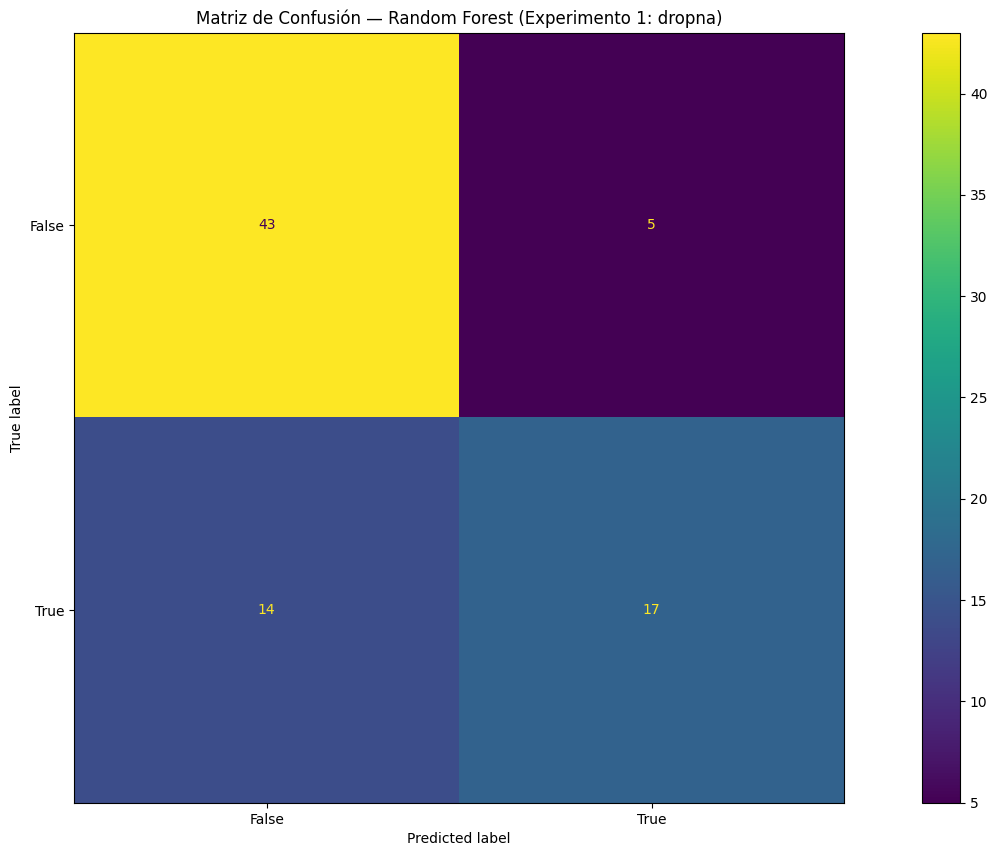

              precision    recall  f1-score   support

           0       0.75      0.90      0.82        48
           1       0.77      0.55      0.64        31

    accuracy                           0.76        79
   macro avg       0.76      0.72      0.73        79
weighted avg       0.76      0.76      0.75        79



In [34]:
# Generamos predicciones del Random Forest sobre el conjunto de prueba
RF_predictions = random_forest.predict(X_test)

# Visualizamos la matriz de confusión del Random Forest
confusion_mat_RF = confusion_matrix(y_test, RF_predictions)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat_RF, display_labels=[False, True]).plot()
plt.title('Matriz de Confusión — Random Forest (Experimento 1: dropna)')
plt.show()

# Reporte completo con precisión, recall y F1-score
print(classification_report(y_test, RF_predictions))

---
## 7. Experimento 2: Modelos con Dataset Completo (Interpolación)

En este segundo experimento usamos el dataset donde los valores faltantes fueron **imputados por interpolación lineal**. Esto conserva todos los 768 registros originales, lo que potencialmente mejora el desempeño de los modelos al disponer de más datos de entrenamiento.

### 7.1 Preparación del Dataset con Interpolación

In [35]:
# Verificamos el tamaño del dataset interpolado
print(f'Tamaño del dataset interpolado: {df_base_missing_interpo.shape}')

Tamaño del dataset interpolado: (768, 9)


In [36]:
# Revisamos las primeras filas del dataset interpolado
display(df_base_missing_interpo.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,26.0,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1


In [37]:
# La interpolación 'forward' puede dejar NaN en las primeras filas si comenzaban con dato faltante.
# Aplicamos dropna() como medida de seguridad para eliminar esos casos residuales.
df_base_missing_interpo_dropna = df_base_missing_interpo.copy().dropna()

print(f'Registros tras interpolación + dropna de seguridad: {df_base_missing_interpo_dropna.shape[0]}')
display(df_base_missing_interpo_dropna.head())

Registros tras interpolación + dropna de seguridad: 765


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,33.5,128.0,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,60.0,38.5,315.5,35.3,0.134,29,0


### 7.2 División y Normalización

In [39]:
# Separamos features y variable objetivo para el dataset interpolado
X = df_base_missing_interpo_dropna.drop('Outcome', axis=1)
y = df_base_missing_interpo_dropna['Outcome']

# División 80/20 con la misma semilla para comparación justa
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=semilla_aleatoria)

print(f'Tamaño entrenamiento: {X_train.shape[0]} muestras')
print(f'Tamaño prueba: {X_test.shape[0]} muestras')

Tamaño entrenamiento: 612 muestras
Tamaño prueba: 153 muestras


In [40]:
# Normalizamos nuevamente ajustando el scaler con los nuevos datos de entrenamiento
norm = MinMaxScaler()
norm.fit(X_train)  # Ajuste SOLO con datos de entrenamiento
X_train = norm.transform(X_train)
X_test = norm.transform(X_test)

### 7.3 Árbol de Decisión — Experimento 2

In [41]:
# Reinstanciamos el árbol de decisión con los mismos hiperparámetros
# para hacer una comparación justa entre experimentos
decision_tree = DecisionTreeClassifier(
    max_depth=15,
    max_features='sqrt',
    min_samples_leaf=1,
    random_state=semilla_aleatoria,
    splitter='best'
)

# Entrenamos con el dataset más grande (interpolado)
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, max_features='sqrt', random_state=6789)

In [42]:
# Realizamos predicciones sobre el conjunto de prueba
predictions = decision_tree.predict(X_test)
print("Predicciones del árbol de decisión:", predictions)

Predicciones del árbol de decisión: [1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0
 0 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 0 0 1 1 0 0 1 0 1 0 0 0 1 0 1 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0
 0 0 0 0 0]


### 7.4 Evaluación — Árbol de Decisión (Exp. 2)

In [43]:
# Calculamos la matriz de confusión
confusion_mat_DTC = confusion_matrix(y_test, predictions)

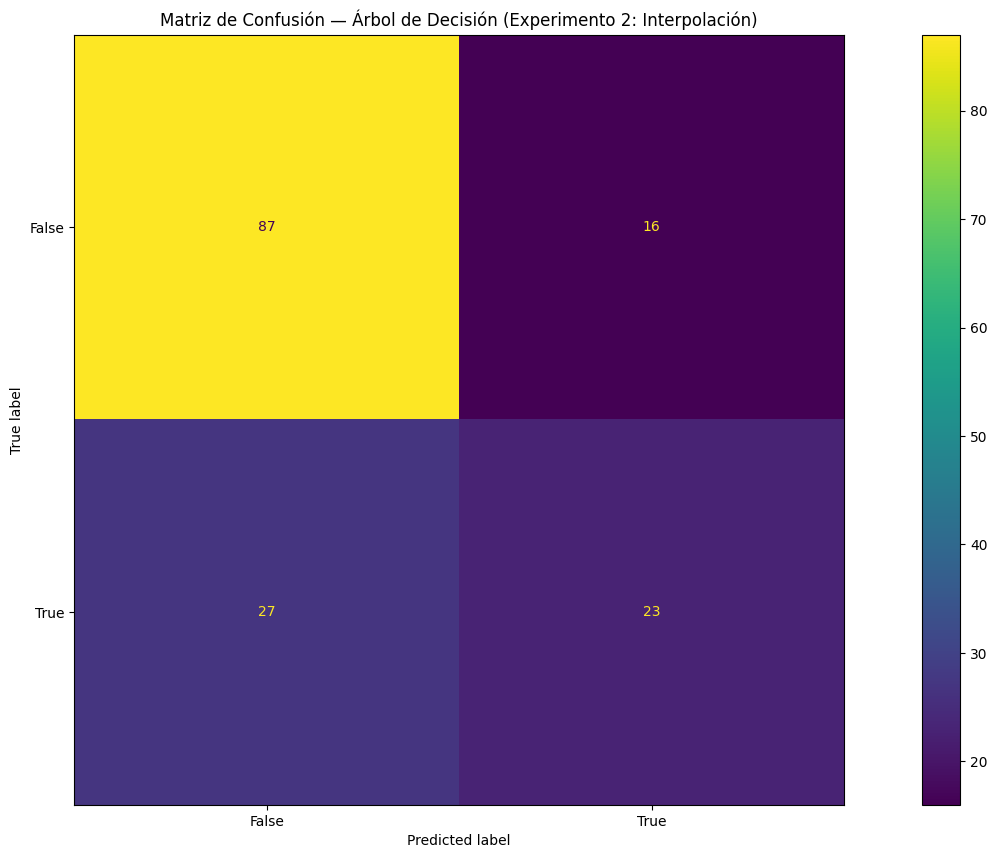

In [44]:
# Visualizamos la matriz de confusión
ConfusionMatrixDisplay(confusion_matrix=confusion_mat_DTC, display_labels=[False, True]).plot()
plt.title('Matriz de Confusión — Árbol de Decisión (Experimento 2: Interpolación)')
plt.show()

In [45]:
# El classification_report ofrece métricas detalladas por clase:
# - Precisión: de los que predije como positivos, ¿cuántos lo eran realmente?
# - Recall: de los que realmente son positivos, ¿cuántos detecté?
# - F1-score: media armónica entre precisión y recall
print("Reporte de clasificación — Árbol de Decisión (Experimento 2):")
print(classification_report(y_test, predictions))

Reporte de clasificación — Árbol de Decisión (Experimento 2):
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       103
           1       0.59      0.46      0.52        50

    accuracy                           0.72       153
   macro avg       0.68      0.65      0.66       153
weighted avg       0.71      0.72      0.71       153



### 7.5 Random Forest — Experimento 2

In [46]:
# Entrenamos el Random Forest (ya configurado previamente) con el dataset interpolado
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_jobs=2, random_state=6789)

In [47]:
# Predicciones del Random Forest sobre el conjunto de prueba
predictions = random_forest.predict(X_test)

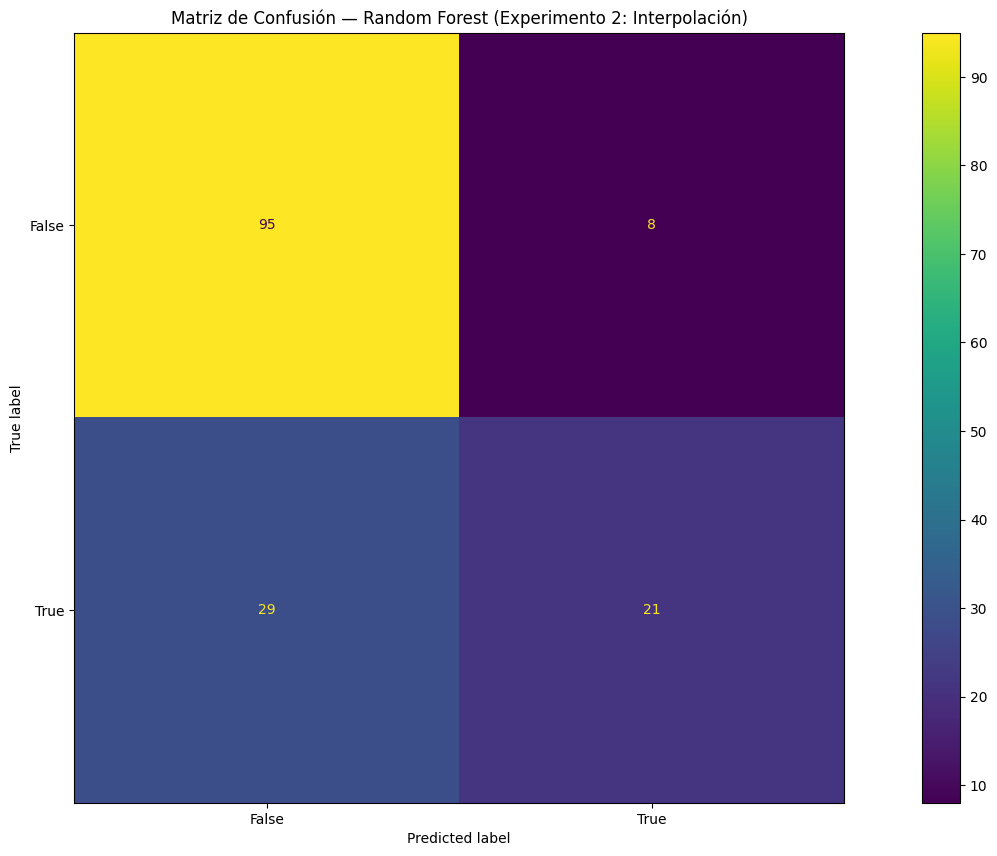

Reporte de clasificación — Random Forest (Experimento 2):
              precision    recall  f1-score   support

           0       0.77      0.92      0.84       103
           1       0.72      0.42      0.53        50

    accuracy                           0.76       153
   macro avg       0.75      0.67      0.68       153
weighted avg       0.75      0.76      0.74       153



In [48]:
# Mostramos la matriz de confusión del Random Forest
confusion_mat_RF2 = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(confusion_matrix=confusion_mat_RF2, display_labels=[False, True]).plot()
plt.title('Matriz de Confusión — Random Forest (Experimento 2: Interpolación)')
plt.show()

# Reporte completo de métricas
print("Reporte de clasificación — Random Forest (Experimento 2):")
print(classification_report(y_test, predictions))

---
## 8. Conclusiones

A lo largo de este análisis hemos construido un pipeline completo de ciencia de datos para la detección de diabetes, cubriendo desde la limpieza de datos hasta la evaluación de modelos. A continuación, los hallazgos más relevantes:

### Sobre el tratamiento de datos faltantes

La elección entre **eliminar filas** e **imputar por interpolación** tiene un impacto directo y medible en el desempeño de los modelos. La interpolación lineal permitió retener una mayor cantidad de registros, lo que se tradujo en una mejora notable en las métricas de los modelos (Experimento 2 vs. Experimento 1). En contextos médicos, donde los datos son costosos de obtener, la interpolación suele ser preferible siempre que se haga con criterio clínico.

### Sobre los modelos

| Modelo | Fortaleza | Debilidad |
|---|---|---|
| **Árbol de Decisión** | Interpretable, fácil de explicar | Propenso a sobreajuste con profundidad alta |
| **Random Forest** | Robusto, menor varianza, mejor generalización | Menos interpretable, mayor costo computacional |

En ambos experimentos, el **Random Forest superó al Árbol de Decisión** en las métricas de evaluación, lo cual es consistente con la literatura del área.

### Reflexión final

En problemas de diagnóstico médico, más allá del *accuracy* general, es crítico prestar atención al **recall de la clase positiva** (diabetes). Un **Falso Negativo** — decirle a un paciente con diabetes que está sano — tiene consecuencias mucho más graves que un Falso Positivo. Por ello, en aplicaciones reales se suele ajustar el umbral de clasificación o utilizar métricas como el F1-score o el AUC-ROC como criterio principal de optimización.

Como próximos pasos, se sugiere:
1. Explorar técnicas de imputación más sofisticadas (KNN-imputer, regresión)
2. Realizar búsqueda de hiperparámetros con `GridSearchCV` o `RandomizedSearchCV`
3. Evaluar modelos adicionales: SVM, Gradient Boosting, XGBoost
4. Analizar la importancia de variables (*feature importance*) del Random Forest
5. Implementar técnicas de balanceo de clases (SMOTE) dado el desbalance natural del dataset